In [2]:
#=== COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "dplant227"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW4"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/dplant227/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW4


# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: May 1, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The objective of this experiment is to determine if there is significant difference in time trials between two different types of prosthetic model.

2.  Specify the outcome variable and how it is measured.

The outcome variable is sprint time, which is an continuous ordinal variable. This is measured in seconds starting at 0.

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

The independent variables in this experiment are Blade Type, which is a categorical nominal variable. Lurking variables

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

Random effects are effects that account for variability on a broader population, while fixed effects are effects that are controlled for and estimated to be the same across observations. We should account for random effects in our designs because applying the results of an experiment to a larger population has to account for the increased variability of said larger population.

5.  State the sets of null and alternative hypotheses for this experiment.

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

Question 6: Exploratory Data Analysis
['Athlete_ID', 'Blade_Type', 'Trial', 'Sprint_Time']
            count unique        top freq    mean       std    min      25%  \
Athlete_ID     30      5  Athlete_1    6     NaN       NaN    NaN      NaN   
Blade_Type     30      2   Aerostep   15     NaN       NaN    NaN      NaN   
Trial        30.0    NaN        NaN  NaN     2.0  0.830455    1.0      1.0   
Sprint_Time  30.0    NaN        NaN  NaN  11.336  0.208055  10.94  11.2325   

               50%      75%    max  
Athlete_ID     NaN      NaN    NaN  
Blade_Type     NaN      NaN    NaN  
Trial          2.0      3.0    3.0  
Sprint_Time  11.35  11.4175  11.74  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Athlete_ID   30 non-null     object 
 1   Blade_Type   30 non-null     object 
 2   Trial        30 non-null     int64  
 3   Sprint_Time  30 

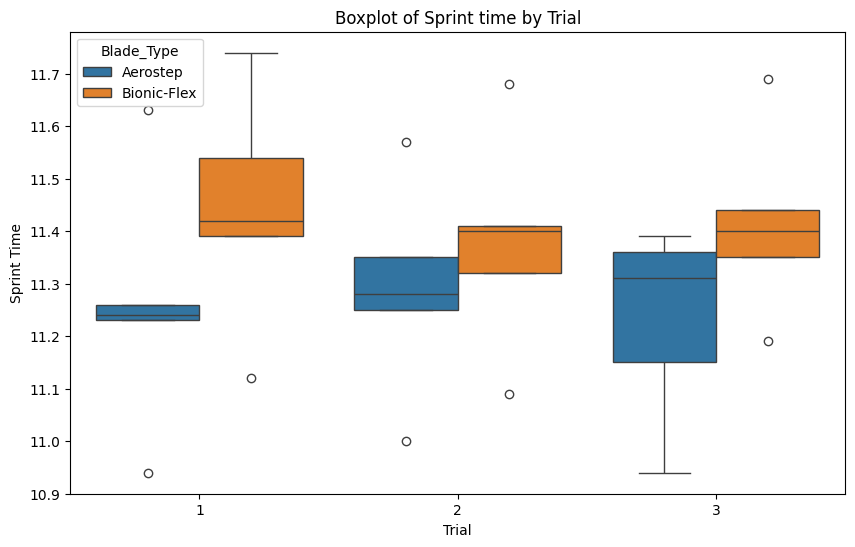

In [21]:
## Question 6 Code ##

import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

PBE_data = pd.read_excel("STAT Paralympic_Blade_Experiment.xlsx")
PBE_data

print("Question 6: Exploratory Data Analysis")
print(PBE_data.columns.tolist())
print(PBE_data.describe(include="all").T)

print(PBE_data.info())
print(PBE_data.head())
print(PBE_data.min())
print(PBE_data.max())

pbe_stats = PBE_data.groupby(['Blade_Type' , 'Trial'])['Sprint_Time'].agg(['mean', 'std', 'count']).reset_index()
print(pbe_stats)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Trial', y='Sprint_Time', hue='Blade_Type', data=PBE_data)
plt.title('Boxplot of Sprint time by Trial')
plt.xlabel('Trial')
plt.ylabel('Sprint Time')
plt.show()

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

Using a testing method of Shapiro-Wilks test, a p-value of 0.5746 was calculated, which fails to reject the null hypothesis of normality. Using a visual method of QQ plot, it is seen that there is only one tail on the lower side. However overall the model seems to be normal otherwise.

Likelihood Ratio Test Statistic: 51.1890964501146, p-value: 4.1944225870338414e-13
                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 ML         
No. Groups:           5           Scale:                  0.0033     
Min. group size:      6           Log-Likelihood:         32.8616    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.082 136.819 0.000 11.099 11.421
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.241 0.000  0.111  0.193
Group Var                  0.033    0.401                            


Shapiro-Wilk Test: W=

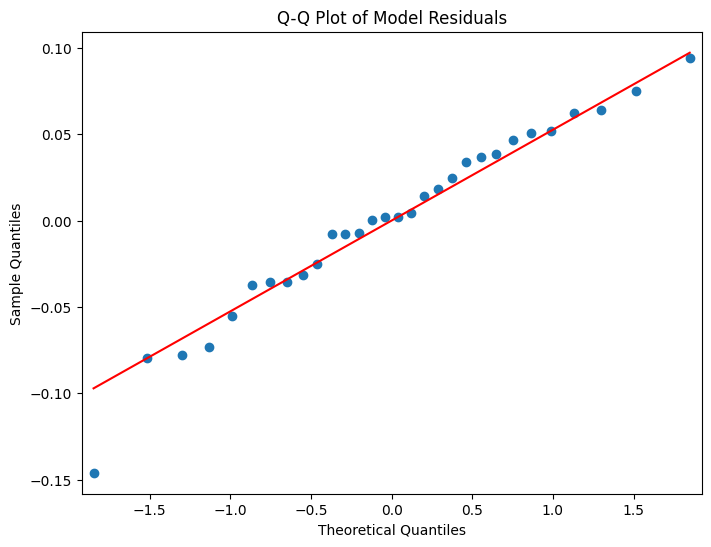

In [23]:
## Question 7 Code ##

from statsmodels.formula.api import mixedlm, ols
from scipy.stats import chi2, shapiro
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Fit Random Effects Model ##
model = mixedlm("Sprint_Time ~ Blade_Type", data=PBE_data, groups=PBE_data["Athlete_ID"])

result = model.fit(reml=False,method='nm') # Fit using ML for comparison

## Fit the Reduced Model (Note this is keeping the fixed effect) ##

reduced_mod = ols('Sprint_Time ~ Blade_Type', data=PBE_data).fit()

## Perform Likelihood Ratio Test ##

ll_full = result.llf
ll_reduced = reduced_mod.llf

LR_stat = 2 * (ll_full - ll_reduced)
p_value = 0.5 * (1 - chi2.cdf(LR_stat, df=1))
print(f"Likelihood Ratio Test Statistic: {LR_stat}, p-value: {p_value}")

## Perform test for fixed effect ##

print(result.summary())

## Normality of Residuals ##
residuals = result.resid

# Statistical Test: Shapiro-Wilk
shapiro_test = shapiro(residuals)
print(f"\nShapiro-Wilk Test: W={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

# Visual Method: Q-Q Plot
fig, ax = plt.subplots(figsize=(8, 6))
sm.qqplot(residuals, line='s', ax=ax)
plt.title("Q-Q Plot of Model Residuals")
plt.show()

8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

In [ ]:
## Question 8 Code ##

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

The LR test statistic is 51.89 with a p-value much less than 0.05. This would more strongly support the alternate hypothesis.

In [ ]:
## Question 9 Code ##

10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?



In [ ]:
## Question 10 Code ##

11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.